# DR-02: Evaluation against the labelled dataset

**FIT3164 · Group DS-25 · LLM email assistant**

The requirements traceability matrix defines DR-02 as:

> *"Labelled dataset is ground truth : accuracy, precision, recall, F1, matrix"*

This notebook is that deliverable. It treats `eval/data/dataset.csv` (DR-01: 400 emails,
100 per class) as ground truth and reports, for the shipped configuration (`gpt-4o-mini`,
one email per call, run 13):

| § | Content |
|---|---|
| 1 | The dataset: size, class balance, and the composition columns that must not be collapsed |
| 2 | The dev/test split, and which saved run each prediction file actually is |
| 3 | How every metric here is defined |
| 4 | **FR-02** accuracy, per-class precision / recall / F1, macro-F1 |
| 5 | **Confusion matrix**, as a table and as a plot |
| 6 | The same metrics split by `text_origin`: the number that matters most |
| 7 | Coverage vs accuracy: why one figure is never enough |
| 8 | **FR-01 / FR-03** groundedness, with claims-checked |
| 9 | One email per call vs 20 per call, on rows no configuration had seen |
| 10 | Limitations: what these numbers do not support |
| 11 | DR-02 coverage checklist |

### This notebook makes no model calls

The project runs under a \$5/week API budget. Every figure below is computed from
prediction files saved by earlier runs of `eval/evaluate_classifier.py` and
`eval/evaluate_grounding.py`. Re-running the classifier to regenerate a number that is
already on disk would spend budget to learn nothing.

The consequence is a real constraint, stated up front: **these are single-run figures**.
§10.2 shows why, for this configuration, that costs little: two separate executions of it
agreed on every prediction.

### Relationship to `eval/BENCHMARKS.md`

`BENCHMARKS.md` is the written record of every run. This notebook recomputes from the raw
per-row files instead of restating it, and then **checks itself against that record** in
§2, and against the dataset's own documentation in §1. Everything reconciles: every saved
prediction file reproduces the run it is recorded as, to the decimal place quoted, except
`dev_preds.csv`, which `BENCHMARKS.md` identifies as an incomplete run and which no figure
here uses.

## 0 · Setup

`pandas`, `numpy` and `matplotlib` only: all three are already project dependencies. No
`seaborn`, no `scikit-learn`: the metric definitions below are written out by hand so they
match `eval/evaluate_classifier.py` exactly (its per-class recall counts abstentions as
misses, which `sklearn.metrics` would not do: see §3).

In [1]:
import re
import sys
import math
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)


def find_root(start=None):
    """Locate the repository root, so the notebook runs from anywhere."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "eval" / "data" / "dataset.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the repo root (no eval/data/dataset.csv above "
        f"{here}). Run: python -m eval.build_dataset --merge"
    )


ROOT = find_root()
DATA = ROOT / "eval" / "data"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `backend.*` imports work from eval/ (§8 only)

print(f"repo root   {ROOT}")
print(f"data        {DATA}")
print(f"pandas {pd.__version__} · numpy {np.__version__} · matplotlib {mpl.__version__}")
print()
print("Saved files this notebook reads (nothing here is regenerated):")
for name in ["dataset.csv", "test_preds_run13.csv", "test_preds_run12.csv",
             "test_preds_run11_per_email.csv", "test_preds_mini.csv",
             "holdout_preds_per_email.csv", "holdout_preds_batch20.csv",
             "holdout_unscored.csv", "test_preds.csv", "predictions.csv", "dev_preds.csv",
             "grounding_summarise.csv", "grounding_draft.csv", "review_work.csv",
             "compare/classify_gpt-4o-mini+unbatched_test_r1.csv"]:
    path = DATA / name
    state = f"{path.stat().st_size / 1024:8.1f} KiB" if path.exists() else "   MISSING"
    print(f"  {name:52} {state}")

repo root   C:\Projects\FIT3164
data        C:\Projects\FIT3164\eval\data
pandas 2.2.1 · numpy 1.26.4 · matplotlib 3.10.6

Saved files this notebook reads (nothing here is regenerated):
  dataset.csv                                             431.5 KiB
  test_preds_run13.csv                                     28.4 KiB
  test_preds_run12.csv                                     27.1 KiB
  test_preds_run11_per_email.csv                           27.0 KiB
  test_preds_mini.csv                                      22.2 KiB
  holdout_preds_per_email.csv                              15.1 KiB
  holdout_preds_batch20.csv                                15.5 KiB
  holdout_unscored.csv                                    128.2 KiB
  test_preds.csv                                           28.2 KiB
  predictions.csv                                          51.1 KiB
  dev_preds.csv                                            23.1 KiB
  grounding_summarise.csv                                   5.2 Ki

### Plot styling

One place, so every figure is consistent: a single-hue blue ramp for magnitude (the
confusion matrix), and a fixed three-slot categorical order for series identity. The
categorical slots are assigned in fixed order and never recycled, so a colour always means
the same thing across figures. Every chart is also printed as a table immediately above
it: the numbers never live only in an image.

In [2]:
INK, INK_2, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]          # fixed categorical order
SEQ_BLUE = LinearSegmentedColormap.from_list(       # light -> dark, one hue
    "seq_blue",
    ["#fcfcfb", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281"],
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "font.size": 10, "text.color": INK,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.grid": False,
    "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False,
})


def tidy(ax, ygrid=True):
    """Hairline, recessive chrome: no box, solid gridlines one shade off the surface."""
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    if ygrid:
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color=GRID, linewidth=0.8, linestyle="-")
    ax.tick_params(length=0)
    return ax


print("styling ready")

styling ready


## 1 · The labelled dataset (DR-01)

DR-02 can only be as good as the ground truth it scores against, so the dataset is
described before any metric is quoted.

Each row carries three separate provenance columns, and `eval/data/README.md` is emphatic
that they answer different questions and must not be merged into one "is it fake" flag:

- **`provenance`**: which corpus the *text* came from (`enron`, `generated`).
- **`text_origin`**: whether the text is genuine human-written mail (`real`) or
  model-written (`synthetic`).
- **`label_source`**: who decided the *label* (`human`, `generation_prompt`).

The reason they are separate is a trade-off:

> A **generated** email has its label by construction (the model was told which class to
> write) but it is not real mail. An **Enron** email is unquestionably real, and its label
> is only as good as the person who read it.

Every real row's label was read and decided by a person (`label_source = human`; §10.1
says how the Work class got there). What remains is the text side of the trade-off: one
class is entirely generated, and the confound check below shows what that does to any
pooled figure. §6 and §10 depend on that distinction, so it is carried through every table
in this notebook.

In [3]:
ds = pd.read_csv(DATA / "dataset.csv")
DATASET_COLUMNS = list(ds.columns)   # as stored on disk, before this notebook derives any
CLASSES = ["Work", "Personal", "Promotions", "Studies"]
REVIEW = "Review"

print(f"rows                {len(ds)}")
print(f"columns             {list(ds.columns)}")
print(f"duplicate ids       {int(ds['id'].duplicated().sum())}")
print(f"rows with empty body {int(ds['body'].isna().sum() + (ds['body'].astype(str).str.strip() == '').sum())}")
print()
print("Class balance")
print(ds["category"].value_counts().reindex(CLASSES).to_frame("rows").to_string())

rows                400
columns             ['id', 'provenance', 'text_origin', 'label_source', 'label_confidence', 'category', 'subject', 'body', 'sender', 'received_at', 'source_ref']
duplicate ids       0
rows with empty body 0

Class balance
            rows
category        
Work         100
Personal     100
Promotions   100
Studies      100


In [4]:
print("Composition: one table per provenance column, none of them collapsed\n")
for col in ["provenance", "text_origin", "label_source", "label_confidence"]:
    counts = ds[col].value_counts()
    share = (counts / len(ds) * 100).round(1)
    print(f"{col}")
    print(pd.DataFrame({"rows": counts, "%": share}).to_string(), "\n")

print("The joint structure: how the three columns line up with the label")
joint = (ds.groupby(["provenance", "text_origin", "label_source", "label_confidence",
                     "category"], as_index=False)
           .size().rename(columns={"size": "rows"}))
print(joint.to_string(index=False))

Composition: one table per provenance column, none of them collapsed

provenance
            rows     %
provenance            
enron        300  75.0
generated    100  25.0 

text_origin
             rows     %
text_origin            
real          300  75.0
synthetic     100  25.0 

label_source
                   rows     %
label_source                 
human               300  75.0
generation_prompt   100  25.0 

label_confidence
                  rows      %
label_confidence             
strong             400  100.0 

The joint structure: how the three columns line up with the label
provenance text_origin      label_source label_confidence   category  rows
     enron        real             human           strong   Personal   100
     enron        real             human           strong Promotions   100
     enron        real             human           strong       Work   100
 generated   synthetic generation_prompt           strong    Studies   100


In [5]:
# The confound, stated as a number: is class independent of text_origin?
print("category x text_origin\n")
confound = pd.crosstab(ds["category"], ds["text_origin"]).reindex(CLASSES)
for col in ["real", "synthetic"]:
    if col not in confound:
        confound[col] = 0
print(confound[["real", "synthetic"]].to_string())

synth_only = [c for c in CLASSES if confound.loc[c, "real"] == 0 and confound.loc[c, "synthetic"] > 0]
real_only = [c for c in CLASSES if confound.loc[c, "synthetic"] == 0 and confound.loc[c, "real"] > 0]
print(f"\nclasses that are ENTIRELY synthetic : {synth_only or 'none'}")
print(f"classes that are ENTIRELY real      : {real_only or 'none'}")
print(f"\nNo class mixes the two origins: "
      f"{all(0 in (confound.loc[c, 'real'], confound.loc[c, 'synthetic']) for c in CLASSES)}")
print("=> class and text_origin are perfectly confounded in this dataset. Any pooled")
print("   accuracy therefore contains an unknown amount of 'can the model tell real mail")
print("   from model-written mail', which is not what FR-02 asks. §6 separates them.")

category x text_origin

text_origin  real  synthetic
category                    
Work          100          0
Personal      100          0
Promotions    100          0
Studies         0        100

classes that are ENTIRELY synthetic : ['Studies']
classes that are ENTIRELY real      : ['Work', 'Personal', 'Promotions']

No class mixes the two origins: True
=> class and text_origin are perfectly confounded in this dataset. Any pooled
   accuracy therefore contains an unknown amount of 'can the model tell real mail
   from model-written mail', which is not what FR-02 asks. §6 separates them.


### A documentation check

`eval/data/README.md` documents a specific composition. It is worth testing that the file
on disk still matches it, because a stale description of ground truth silently invalidates
every number computed from it.

In [6]:
# Transcribed from eval/data/README.md ("Current merged set") purely to test the file
# against its own documentation. These values are NOT used to produce any reported figure.
README_DOCUMENTED = {
    "total rows": 400,
    "Work": 100, "Personal": 100, "Promotions": 100, "Studies": 100,
    "real": 300, "synthetic": 100,
    "provenance=enron": 300, "provenance=huggingface": 0, "provenance=generated": 100,
    "label_source=human": 300, "label_source=generation_prompt": 100,
    "label_source=folder_heuristic": 0,
}
actual = {
    "total rows": len(ds),
    **{c: int((ds["category"] == c).sum()) for c in CLASSES},
    **{o: int((ds["text_origin"] == o).sum()) for o in ["real", "synthetic"]},
    **{f"provenance={p}": int((ds["provenance"] == p).sum())
       for p in ["enron", "huggingface", "generated"]},
    **{f"label_source={s}": int((ds["label_source"] == s).sum())
       for s in ["human", "generation_prompt", "folder_heuristic"]},
}
check = pd.DataFrame({"README.md documents": pd.Series(README_DOCUMENTED),
                      "dataset.csv contains": pd.Series(actual)})
check["agrees"] = check["README.md documents"] == check["dataset.csv contains"]
print(check.to_string())
print(f"\nrows of documentation that disagree with the file: "
      f"{int((~check['agrees']).sum())} of {len(check)}")

                                README.md documents  dataset.csv contains  agrees
total rows                                      400                   400    True
Work                                            100                   100    True
Personal                                        100                   100    True
Promotions                                      100                   100    True
Studies                                         100                   100    True
real                                            300                   300    True
synthetic                                       100                   100    True
provenance=enron                                300                   300    True
provenance=huggingface                            0                     0    True
provenance=generated                            100                   100    True
label_source=human                              300                   300    True
label_source=gen

**Finding: the documentation agrees with the file.** All 13 documented figures match
`dataset.csv`: 400 rows, 100 per class, 300 real Enron emails with human-verified labels
and 100 generated Studies emails, and no `huggingface` or `folder_heuristic` rows. An
earlier version of this notebook found the README a dataset behind; it has since been
brought in line, and this cell is what would catch it drifting again.

What has *not* changed is the README's argument, and it still governs §6 and §10: class
and `text_origin` remain perfectly confounded. Studies is the only class with generated
text and has no real mail at all, so the reason for never pooling did not go away.

## 2 · The split, and what each saved prediction file is

`evaluate_classifier.py` assigns each row to **dev** (40%) or **test** (60%) by hashing its
`id` (not by storing a flag), so the split is reproducible from the CSV alone and cannot
drift as rows are added. Prompts and the model choice were tuned on dev; the reported
figure is measured once on test.

This matters more than it looks. A prompt tuned against the rows it is then scored on has
been fitted to the test set, and the resulting figure describes the tuning rather than the
system. The function below is a copy of `_split_of`, so the notebook can prove which split
each saved file covers instead of trusting its filename.

In [7]:
DEV_FRACTION = 40   # percent, as in eval/evaluate_classifier.py


def split_of(row_id: str) -> str:
    digest = hashlib.sha1(row_id.encode("utf-8")).hexdigest()
    return "dev" if int(digest[:8], 16) % 100 < DEV_FRACTION else "test"


ds["split"] = ds["id"].map(split_of)
print("Split sizes")
print(ds["split"].value_counts().to_frame("rows").to_string())
print()
print("Class balance per split: the test split is NOT perfectly balanced")
print(pd.crosstab(ds["category"], ds["split"]).reindex(CLASSES).to_string())
print("\nThis is why macro-F1 (unweighted mean over classes) is reported alongside")
print("accuracy: with unequal support, accuracy quietly weights the larger classes.")

Split sizes
       rows
split      
test    226
dev     174

Class balance per split: the test split is NOT perfectly balanced
split       dev  test
category             
Work         34    66
Personal     48    52
Promotions   50    50
Studies      42    58

This is why macro-F1 (unweighted mean over classes) is reported alongside
accuracy: with unequal support, accuracy quietly weights the larger classes.


In [8]:
# Every saved per-row prediction file, newest first. Only the first is on today's
# dataset; the rest are kept because eval/BENCHMARKS.md quotes them as history.
PRED_FILES = {
    "test_preds_run13.csv":           "run 13: today's test split (shipped)",
    "test_preds_run12.csv":           "run 12: 376-row set",
    "test_preds_run11_per_email.csv": "run 11: 376-row set",
    "test_preds_mini.csv":            "run 10: 376-row set, 20 per call",
    "holdout_preds_per_email.csv":    "holdout, one email per call",
    "holdout_preds_batch20.csv":      "holdout, 20 per call",
    "test_preds.csv":                 "run 7: gpt-4o, 480-row set",
    "predictions.csv":                "run 2: 480-row set",
    "dev_preds.csv":                  "dev split, 480-row set",
}
TEST_IDS = set(ds.loc[ds["split"] == "test", "id"])
preds = {}
rows = []
for name, note in PRED_FILES.items():
    path = DATA / name
    if not path.exists():
        print(f"  MISSING {name}")
        continue
    df = pd.read_csv(path, keep_default_na=False)
    preds[name] = df
    ids = set(df["id"])
    rows.append({
        "file": name, "n": len(df),
        "rows in dataset.csv": len(ids & set(ds["id"])),
        "is today's test split": ids == TEST_IDS,
        "correct col consistent": bool((df["correct"].astype(str) == (df["expected"] == df["predicted"]).astype(str)).all()),
        "note": note,
    })
print(pd.DataFrame(rows).to_string(index=False))

                          file   n  rows in dataset.csv  is today's test split  correct col consistent                                 note
          test_preds_run13.csv 226                  226                   True                    True run 13: today's test split (shipped)
          test_preds_run12.csv 215                  210                  False                    True                  run 12: 376-row set
test_preds_run11_per_email.csv 215                  210                  False                    True                  run 11: 376-row set
           test_preds_mini.csv 215                  210                  False                    True     run 10: 376-row set, 20 per call
   holdout_preds_per_email.csv 123                   17                  False                    True          holdout, one email per call
     holdout_preds_batch20.csv 123                   17                  False                    True                 holdout, 20 per call
                test

### Which recorded run is which file?

`BENCHMARKS.md` lists thirteen numbered runs and two holdout runs. Rather than assume the
filenames, the cell below recomputes each file's headline triple and looks for the
recorded run it matches. The run history is transcribed for this comparison only: **it
produces no reported figure in this notebook**, and every "computed" column beside it
comes from the CSVs.

In [9]:
def headline(df):
    """coverage / accuracy-over-covered / strict, as defined in §3."""
    total = len(df)
    covered = df[df["predicted"] != REVIEW]
    correct = int((covered["expected"] == covered["predicted"]).sum())
    return {
        "coverage": len(covered) / total,
        "accuracy": correct / len(covered) if len(covered) else 0.0,
        "strict": correct / total,
    }


# Transcribed from the run-history and saved-file tables in eval/BENCHMARKS.md, for
# cross-checking only.
RUN_HISTORY = [
    dict(run="1",  split="all",  n=480, coverage=.825, accuracy=.773, strict=.637),
    dict(run="2",  split="all",  n=480, coverage=.883, accuracy=.755, strict=.667),
    dict(run="3",  split="dev",  n=214, coverage=.921, accuracy=.701, strict=.645),
    dict(run="4",  split="dev",  n=214, coverage=.911, accuracy=.703, strict=.640),
    dict(run="5",  split="dev",  n=214, coverage=.916, accuracy=.724, strict=.664),
    dict(run="6",  split="dev",  n=214, coverage=.907, accuracy=.851, strict=.771),
    dict(run="7",  split="test", n=266, coverage=.891, accuracy=.869, strict=.774),
    dict(run="8",  split="test", n=266, coverage=.929, accuracy=.830, strict=.771),
    dict(run="9",  split="test", n=266, coverage=.921, accuracy=.833, strict=.767),
    dict(run="10", split="test", n=215, coverage=.921, accuracy=.838, strict=.772),
    dict(run="11", split="test", n=215, coverage=.977, accuracy=.929, strict=.907),
    dict(run="12", split="test", n=215, coverage=.995, accuracy=.921, strict=.916),
    dict(run="13", split="test", n=226, coverage=.991, accuracy=.906, strict=.898),
    dict(run="holdout, 1 per call",  split="holdout", n=123, coverage=.967, accuracy=.899, strict=.870),
    dict(run="holdout, 20 per call", split="holdout", n=123, coverage=.829, accuracy=.765, strict=.634),
]
TOL = 0.001   # the record is quoted to 0.1 pp, so match to that resolution

out = []
for name, df in preds.items():
    h = headline(df)
    hits = [r for r in RUN_HISTORY
            if r["n"] == len(df)
            and all(abs(h[k] - r[k]) <= TOL for k in ("coverage", "accuracy", "strict"))]
    out.append({
        "file": name,
        "computed coverage": f"{h['coverage']:.1%}",
        "computed accuracy": f"{h['accuracy']:.1%}",
        "computed strict": f"{h['strict']:.1%}",
        "matches recorded run": ", ".join(r["run"] for r in hits) if hits else "NO MATCH",
    })
print(pd.DataFrame(out).to_string(index=False))

print("\nNearest recorded run for any file that did not match, by total absolute gap:")
for row, (name, df) in zip(out, preds.items()):
    if row["matches recorded run"] != "NO MATCH":
        continue
    h = headline(df)
    cands = [r for r in RUN_HISTORY if r["n"] == len(df)] or RUN_HISTORY
    best = min(cands, key=lambda r: sum(abs(h[k] - r[k]) for k in ("coverage", "accuracy", "strict")))
    gaps = {k: (h[k] - best[k]) * 100 for k in ("coverage", "accuracy", "strict")}
    print(f"  {name}: nearest is run {best['run']} ({best['split']}), gap in pp "
          + "  ".join(f"{k} {v:+.1f}" for k, v in gaps.items()))

                          file computed coverage computed accuracy computed strict matches recorded run
          test_preds_run13.csv             99.1%             90.6%           89.8%                   13
          test_preds_run12.csv             99.5%             92.1%           91.6%                   12
test_preds_run11_per_email.csv             97.7%             92.9%           90.7%                   11
           test_preds_mini.csv             92.1%             83.8%           77.2%                   10
   holdout_preds_per_email.csv             96.7%             89.9%           87.0%  holdout, 1 per call
     holdout_preds_batch20.csv             82.9%             76.5%           63.4% holdout, 20 per call
                test_preds.csv             89.1%             86.9%           77.4%                    7
               predictions.csv             88.3%             75.5%           66.7%                    2
                 dev_preds.csv             82.2%             78.

**Every file but one reconciles exactly.** Runs 13, 12, 11, 10, 7 and 2 and both holdout
runs recompute to the figures `BENCHMARKS.md` records for them, to the decimal place it
quotes. `test_preds_mini.csv` is run 10, not the run 9 an earlier version of this notebook
read: run 10 reused the path and overwrote it. That is recorded in `BENCHMARKS.md`, and it
is why every run since writes its settings into each row and refuses to replace an
existing file.

**`dev_preds.csv` matches no recorded run**, and `BENCHMARKS.md` explains why: 18 of its
rows were never classified, because one batched response left their ids out. It is an
incomplete run, not a measurement, and **no figure in this notebook is drawn from it.**

Only run 13 covers today's test split (the table above checks the ids, not the filename).
Runs 10 to 12 were measured on the 376-row set that preceded it, and runs 2 and 7 on the
480-row set before that. They are history, quoted in `BENCHMARKS.md`; nothing below is
computed from them except the repeat-run check in §10.2. The reported configuration is
therefore **`test_preds_run13.csv`: `gpt-4o-mini`, one email per call, test split,
n = 226**.

In [10]:
TEST = preds["test_preds_run13.csv"].copy()

# The run recorded its own settings in every row, so they are read, not assumed.
settings = TEST[["model", "classify_batch_size", "classify_concurrency"]].drop_duplicates()
assert len(settings) == 1, "the file mixes settings from more than one run"
MODEL_UNDER_TEST = settings.iloc[0]["model"]
BATCH_SIZE = int(settings.iloc[0]["classify_batch_size"])
CONCURRENCY = int(settings.iloc[0]["classify_concurrency"])

assert set(TEST["id"]) == TEST_IDS, "the run does not cover today's test split"
TEST = TEST.merge(ds[["id", "category"]], on="id", how="left")
assert (TEST["expected"] == TEST["category"]).all(), \
    "saved expected labels disagree with dataset.csv -- the dataset changed after the run"
TEST = TEST.drop(columns=["category"])
TEST["confidence"] = TEST["confidence"].astype(float)

print(f"reported configuration : {MODEL_UNDER_TEST}, {BATCH_SIZE} email per call, "
      f"{CONCURRENCY} calls at once, held-out test split")
print(f"rows                   : {len(TEST)}, exactly today's test split")
print(f"labels verified against dataset.csv : yes, all {len(TEST)} rows agree")

reported configuration : gpt-4o-mini, 1 email per call, 25 calls at once, held-out test split
rows                   : 226, exactly today's test split
labels verified against dataset.csv : yes, all 226 rows agree


## 3 · How these metrics are defined

Three definitions are non-obvious, and quoting the numbers without them would be
misleading.

**1. `Review` is an abstention, not a wrong answer.** The classifier routes an email to
`Review` when the evidence span it quoted cannot be found in the source, or when its
confidence falls below the configured threshold. That is the system working as specified.
Scoring it as a miss understates the classifier; scoring it as a hit would let a model
reach 100% by abstaining on everything. So every result is reported three ways:

| | definition |
|---|---|
| **coverage** | share of rows given a real category rather than `Review` |
| **accuracy** | correct, over **covered rows only**: how good the answers are when it answers |
| **strict** | `Review` counted as wrong: the pessimistic bound over every row |

**2. Precision and recall are deliberately asymmetric.** False positives are counted over
covered rows, because an abstention is not a false claim of any class. False negatives are
counted over **all** rows, so an abstention *does* cost the true class its recall. The
effect is intended: abstaining is free in precision and expensive in recall, which is the
right incentive for a system whose abstention is a safety feature. It also means
`sklearn.metrics` would not reproduce these numbers, which is why they are written out
below rather than imported.

**3. Macro-F1 averages over classes actually present** in the slice, not always over four.
Some breakdown groups in §6 contain a single class, and dividing by four there reported
macro-F1 0.250 for a group the classifier got essentially right: a number that reads as
failure and is not one.

`score()` is a transcription of `_score` in `eval/evaluate_classifier.py`. Same
definitions, same run, recomputed from the per-row file.

In [11]:
def score(expected, predicted, classes=CLASSES):
    """Mirror of eval.evaluate_classifier._score. Returns a dict of metrics."""
    pairs = list(zip(expected, predicted))
    total = len(pairs)
    if not total:
        return None
    reviewed = sum(1 for _, p in pairs if p == REVIEW)
    covered = [(e, p) for e, p in pairs if p != REVIEW]
    correct = sum(1 for e, p in covered if e == p)

    per_class = {}
    for label in classes:
        support = sum(1 for e, _ in pairs if e == label)
        tp = sum(1 for e, p in covered if e == label and p == label)
        fp = sum(1 for e, p in covered if e != label and p == label)   # covered rows only
        fn = sum(1 for e, p in pairs if e == label and p != label)     # ALL rows: Review counts
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        per_class[label] = dict(support=support, tp=tp, fp=fp, fn=fn,
                                precision=precision, recall=recall, f1=f1)

    present = [v["f1"] for v in per_class.values() if v["support"]]
    return dict(
        n=total, reviewed=reviewed,
        coverage=(total - reviewed) / total,
        accuracy=correct / len(covered) if covered else 0.0,
        strict=correct / total,
        macro_f1=sum(present) / len(present) if present else 0.0,
        per_class=per_class,
    )


def triple(m):
    return (f"n={m['n']:<5} coverage={m['coverage']:6.1%}  accuracy(covered)={m['accuracy']:6.1%}"
            f"  strict={m['strict']:6.1%}  macro-F1={m['macro_f1']:.3f}")


# Sanity check on the definitions themselves, not on the model.
_m = score(["Work", "Work", "Personal"], ["Work", REVIEW, "Work"])
assert _m["coverage"] == 2 / 3 and _m["accuracy"] == 0.5 and _m["strict"] == 1 / 3
assert _m["per_class"]["Work"]["fn"] == 1 and _m["per_class"]["Work"]["fp"] == 1
print("score() definitions self-check passed")

score() definitions self-check passed


## 4 · FR-02: classification against ground truth

The headline result for the shipped configuration, and the per-class breakdown DR-02 names.

In [12]:
overall = score(TEST["expected"], TEST["predicted"])
print(f"FR-02 · {MODEL_UNDER_TEST} · held-out test split")
print("=" * 78)
print(triple(overall))
print(f"{'':8}abstained to Review: {overall['reviewed']} of {overall['n']} rows")

FR-02 · gpt-4o-mini · held-out test split
n=226   coverage= 99.1%  accuracy(covered)= 90.6%  strict= 89.8%  macro-F1=0.902
        abstained to Review: 2 of 226 rows


In [13]:
rows = []
for label, s in overall["per_class"].items():
    rows.append({"class": label, "support": s["support"], "TP": s["tp"], "FP": s["fp"],
                 "FN": s["fn"], "precision": s["precision"], "recall": s["recall"], "F1": s["f1"]})
per_class = pd.DataFrame(rows).set_index("class")

fmt = per_class.copy()
for c in ["precision", "recall"]:
    fmt[c] = per_class[c].map("{:.1%}".format)
fmt["F1"] = per_class["F1"].map("{:.3f}".format)
print("Per class, over covered rows (FP over covered; FN over all rows: §3)\n")
print(fmt.to_string())

print(f"\nmacro-F1 (unweighted mean over the {len(per_class)} classes present) "
      f"= {overall['macro_f1']:.3f}")
weighted = float((per_class['F1'] * per_class['support']).sum() / per_class['support'].sum())
print(f"support-weighted mean F1                                     = {weighted:.3f}")
gap = abs(weighted - overall["macro_f1"])
print("\nThe two diverge whenever support is unequal (§2)"
      + (f"; here by {gap:.3f}." if gap >= 0.0005 else "; here they agree to three decimals."))
print("Macro-F1 is the figure to quote: it refuses on principle to let a large, easy")
print("class carry a weak one.")

Per class, over covered rows (FP over covered; FN over all rows: §3)



            support  TP  FP  FN precision recall     F1
class                                                  
Work             66  54   3  12     94.7%  81.8%  0.878
Personal         52  45  10   7     81.8%  86.5%  0.841
Promotions       50  47   6   3     88.7%  94.0%  0.913
Studies          58  57   2   1     96.6%  98.3%  0.974

macro-F1 (unweighted mean over the 4 classes present) = 0.902
support-weighted mean F1                                     = 0.902

The two diverge whenever support is unequal (§2); here they agree to three decimals.
Macro-F1 is the figure to quote: it refuses on principle to let a large, easy
class carry a weak one.


### What the per-class table shows

- **Studies is nearly solved and must not be read as a capability result.** It is the only
  entirely generated class (§1), so its F1 is measuring performance on text a language
  model wrote. §6 separates this out.
- **Work is the weakest class, and it fails asymmetrically**: the highest precision of the
  three real classes (94.7%) and the lowest recall of all four (81.8%). When the model says
  Work it is almost always right; what it misses is Work mail that reads like something
  else, mostly Personal (§5).
- **Personal has the lowest precision (81.8%)**, and it is the same boundary seen from the
  other side: 8 of its 10 false positives are Work emails.
- **Abstention barely touches recall now.** Only 2 of 226 rows went to `Review`, so the
  gaps between precision and recall here are almost entirely real mistakes rather than
  declined answers. Under batched classification that was not true (§9).

## 5 · Confusion matrix

DR-02 asks for the matrix specifically, and this is why: the scalars above say how much is
wrong, and only the matrix says *what is being confused with what*. A five-column matrix is
used (the four classes plus `Review`) because an abstention is a distinct outcome and
folding it into a class would misrepresent the model as having made a claim it did not make.

Rows are the true label, columns the prediction, so each row sums to that class's support.

In [14]:
cm = (pd.crosstab(TEST["expected"], TEST["predicted"])
        .reindex(index=CLASSES, columns=CLASSES + [REVIEW])
        .fillna(0).astype(int))
cm.index.name, cm.columns.name = "true", "predicted"
print("Counts\n")
print(cm.to_string())
print(f"\nrow sums (= support): {cm.sum(axis=1).to_dict()}")
print(f"total: {int(cm.values.sum())} of {len(TEST)} rows accounted for")

row_share = cm.div(cm.sum(axis=1), axis=0)
print("\nRow-normalised (share of each true class): comparable across unequal support\n")
print(row_share.map("{:.1%}".format).to_string())

Counts



predicted   Work  Personal  Promotions  Studies  Review
true                                                   
Work          54         8           4        0       0
Personal       2        45           2        1       2
Promotions     0         2          47        1       0
Studies        1         0           0       57       0

row sums (= support): {'Work': 66, 'Personal': 52, 'Promotions': 50, 'Studies': 58}
total: 226 of 226 rows accounted for

Row-normalised (share of each true class): comparable across unequal support

predicted    Work Personal Promotions Studies Review
true                                                
Work        81.8%    12.1%       6.1%    0.0%   0.0%
Personal     3.8%    86.5%       3.8%    1.9%   3.8%
Promotions   0.0%     4.0%      94.0%    2.0%   0.0%
Studies      1.7%     0.0%       0.0%   98.3%   0.0%


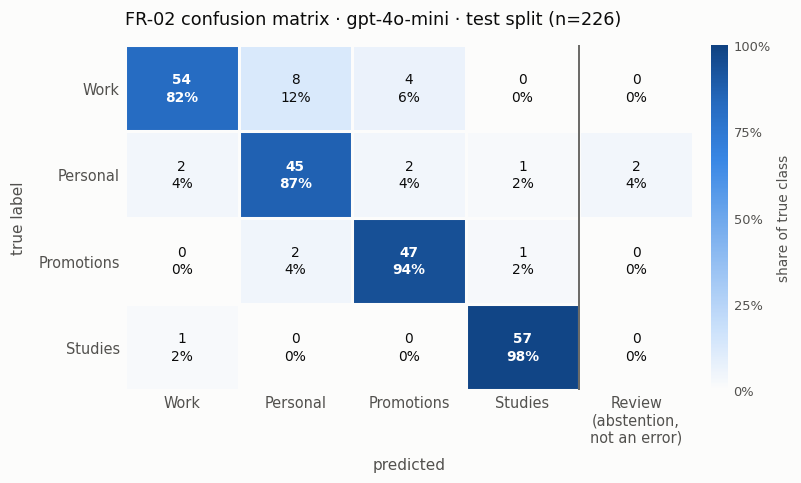

Colour encodes the row-normalised share; the count is printed in every cell.
The diagonal is bold. Counts, not colour, are the record: the table is above.


In [15]:
fig, ax = plt.subplots(figsize=(7.4, 4.5))
data = row_share.values

im = ax.imshow(data, cmap=SEQ_BLUE, vmin=0, vmax=1, aspect="auto")

xlabels = [c if c != REVIEW else f"{REVIEW}\n(abstention,\nnot an error)" for c in cm.columns]
ax.set_xticks(range(len(cm.columns)), xlabels, fontsize=9.5)
ax.set_yticks(range(len(cm.index)), cm.index, fontsize=9.5)
ax.set_xlabel("predicted", color=INK_2, labelpad=8)
ax.set_ylabel("true label", color=INK_2, labelpad=8)
ax.set_title(f"FR-02 confusion matrix · {MODEL_UNDER_TEST} · test split (n={len(TEST)})",
             fontsize=11.5, pad=14, loc="left")

# 2px surface gap between cells instead of borders around them.
ax.set_xticks(np.arange(-.5, len(cm.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(cm.index), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="both", length=0)
for side in ax.spines:
    ax.spines[side].set_visible(False)

# Every cell is labelled: a confusion matrix is a table that happens to be coloured,
# so the count must be legible without reading the colour back off the ramp.
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        n, sh = cm.values[i, j], data[i, j]
        ax.text(j, i, f"{n}\n{sh:.0%}", ha="center", va="center", fontsize=9,
                linespacing=1.35,
                color="#ffffff" if sh > 0.55 else INK,
                fontweight="bold" if i == j else "normal")

# Divide off the abstention column: it is not a class, and not an error either.
ax.axvline(len(CLASSES) - 0.5, color=INK_2, linewidth=1.1)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label("share of true class", color=INK_2, fontsize=9)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, labelsize=8.5, labelcolor=INK_2)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])

fig.tight_layout()
plt.show()

print("Colour encodes the row-normalised share; the count is printed in every cell.")
print("The diagonal is bold. Counts, not colour, are the record: the table is above.")

In [16]:
# Where does each class's error actually go? Review is excluded from "largest
# misclassification" on purpose: it is an abstention, so it is reported in its own
# column rather than competing to be a class's biggest mistake.
print("Largest MISCLASSIFICATION per true class (Review excluded: it is not one)\n")
for label in CLASSES:
    support = cm.loc[label].sum()
    row = cm.loc[label].drop(labels=[label, REVIEW])
    worst = row.idxmax()
    noun = "row " if row[worst] == 1 else "rows"
    print(f"  {label:11} -> {worst:11} {row[worst]:3} {noun} ({row[worst] / support:5.1%} "
          f"of the class)     [abstained: {cm.loc[label, REVIEW]:2} = "
          f"{cm.loc[label, REVIEW] / support:4.1%}]")

pair = pd.DataFrame({
    "A->B": [cm.loc[a, b] for a, b in [("Work", "Promotions"), ("Work", "Personal"),
                                       ("Personal", "Promotions")]],
    "B->A": [cm.loc[b, a] for a, b in [("Work", "Promotions"), ("Work", "Personal"),
                                       ("Personal", "Promotions")]],
}, index=["Work/Promotions", "Work/Personal", "Personal/Promotions"])
pair["asymmetry"] = pair["A->B"] - pair["B->A"]
print("\nIs the confusion symmetric? (A->B vs B->A)\n")
print(pair.to_string())
print("\nA symmetric mix-up looks like a hard boundary between two classes; a one-way")
print("flow says one class's mail keeps reading like the other's. Every real label here")
print("was read by a person (§10.1), so a one-way flow is the model's, not a folder's.")

Largest MISCLASSIFICATION per true class (Review excluded: it is not one)

  Work        -> Personal      8 rows (12.1% of the class)     [abstained:  0 = 0.0%]
  Personal    -> Work          2 rows ( 3.8% of the class)     [abstained:  2 = 3.8%]
  Promotions  -> Personal      2 rows ( 4.0% of the class)     [abstained:  0 = 0.0%]
  Studies     -> Work          1 row  ( 1.7% of the class)     [abstained:  0 = 0.0%]

Is the confusion symmetric? (A->B vs B->A)

                     A->B  B->A  asymmetry
Work/Promotions         4     0          4
Work/Personal           8     2          6
Personal/Promotions     2     2          0

A symmetric mix-up looks like a hard boundary between two classes; a one-way
flow says one class's mail keeps reading like the other's. Every real label here
was read by a person (§10.1), so a one-way flow is the model's, not a folder's.


### Reading the matrix

- **The `Review` column is nearly empty.** Two rows, both Personal, both because the
  quoted evidence was not in the email (§7). One email per call all but removed abstention
  (§9).
- **Most errors sit on one boundary: Work against Personal.** Work flows into Personal
  (8 rows) far more than the reverse (2). `BENCHMARKS.md` names what those emails are:
  recruiting mail, and colleagues writing about life outside work.
- **`Work → Promotions` is one-way too, but small** (4 rows against none).
- **Every real label was read by a person**, so these flows are the classifier's
  disagreements with a human reader, not noise from a folder heuristic. That was not true
  of the earlier 480-row set, and §10.1 shows what correcting it changed.

## 6 · The same metrics, split by `text_origin`

**This is the most important section in the notebook**, and the pooled figure in §4 should
not be quoted without it.

§1 established that class and `text_origin` are perfectly confounded: `Studies` is entirely
generated, everything else is real Enron mail. So a pooled accuracy is a blend of two
different questions: "can it categorise email", which is FR-02, and "can it tell
human-written mail from model-written mail", which is not. Splitting on `text_origin`
separates them.

`provenance` and `label_source` are printed as well, because on an earlier version of the
dataset they divided the rows differently (some real rows had folder-guessed labels). On
today's set they do not, and the cell says so rather than leaving it to be assumed.

In [17]:
def breakdown(df, column):
    out = []
    for key, sub in df.groupby(column, dropna=False):
        m = score(sub["expected"], sub["predicted"])
        out.append({column: key, "n": m["n"], "coverage": m["coverage"],
                    "accuracy": m["accuracy"], "strict": m["strict"],
                    "macro-F1": m["macro_f1"],
                    "classes present": sum(1 for v in m["per_class"].values() if v["support"])})
    table = pd.DataFrame(out).set_index(column).sort_values("n", ascending=False)
    return table


def show(table):
    f = table.copy()
    for c in ["coverage", "accuracy", "strict"]:
        f[c] = table[c].map("{:.1%}".format)
    f["macro-F1"] = table["macro-F1"].map("{:.3f}".format)
    print(f.to_string(), "\n")


by_origin = breakdown(TEST, "text_origin")
print("By text_origin: is the text real human mail, or generated?\n"); show(by_origin)
print("By provenance: which corpus the text came from\n"); show(breakdown(TEST, "provenance"))
print("By label_source: who decided the label\n"); show(breakdown(TEST, "label_source"))

same_rows = (TEST.groupby("text_origin")["label_source"].nunique().eq(1).all()
             and TEST.groupby("label_source")["text_origin"].nunique().eq(1).all())
print(f"label_source and text_origin divide the rows identically: {same_rows}")
print("Every real row is labelled `human` and every synthetic row `generation_prompt`,")
print("so the three tables above are one table printed three times.")

By text_origin: is the text real human mail, or generated?

               n coverage accuracy strict macro-F1  classes present
text_origin                                                        
real         168    98.8%    88.0%  86.9%    0.880                3
synthetic     58   100.0%    98.3%  98.3%    0.991                1 

By provenance: which corpus the text came from

              n coverage accuracy strict macro-F1  classes present
provenance                                                        
enron       168    98.8%    88.0%  86.9%    0.880                3
generated    58   100.0%    98.3%  98.3%    0.991                1 

By label_source: who decided the label

                     n coverage accuracy strict macro-F1  classes present
label_source                                                             
human              168    98.8%    88.0%  86.9%    0.880                3
generation_prompt   58   100.0%    98.3%  98.3%    0.991                1 

label_sour

In [18]:
real_acc = by_origin.loc["real", "accuracy"]
synth_acc = by_origin.loc["synthetic", "accuracy"]
gap_acc = (synth_acc - real_acc) * 100
gap_strict = (by_origin.loc["synthetic", "strict"] - by_origin.loc["real", "strict"]) * 100

print("The size of the effect, in percentage points")
print("=" * 62)
print(f"  accuracy on real email       {real_acc:6.1%}   (n={int(by_origin.loc['real', 'n'])})")
print(f"  accuracy on synthetic email  {synth_acc:6.1%}   (n={int(by_origin.loc['synthetic', 'n'])})")
print(f"  gap                          {gap_acc:+6.1f} pp   (strict: {gap_strict:+.1f} pp)")
print(f"\n  pooled accuracy              {overall['accuracy']:6.1%}")
print(f"  pooled sits {(overall['accuracy'] - real_acc) * 100:+.1f} pp above the real-email "
      f"figure, on a set that is "
      f"{by_origin.loc['synthetic', 'n'] / overall['n']:.0%} synthetic.")
print("\n  A set with more generated rows would raise the pooled number without the")
print("  classifier changing at all. That is the property that makes it unquotable.")

The size of the effect, in percentage points
  accuracy on real email        88.0%   (n=168)
  accuracy on synthetic email   98.3%   (n=58)
  gap                           +10.3 pp   (strict: +11.4 pp)

  pooled accuracy               90.6%
  pooled sits +2.7 pp above the real-email figure, on a set that is 26% synthetic.

  A set with more generated rows would raise the pooled number without the
  classifier changing at all. That is the property that makes it unquotable.


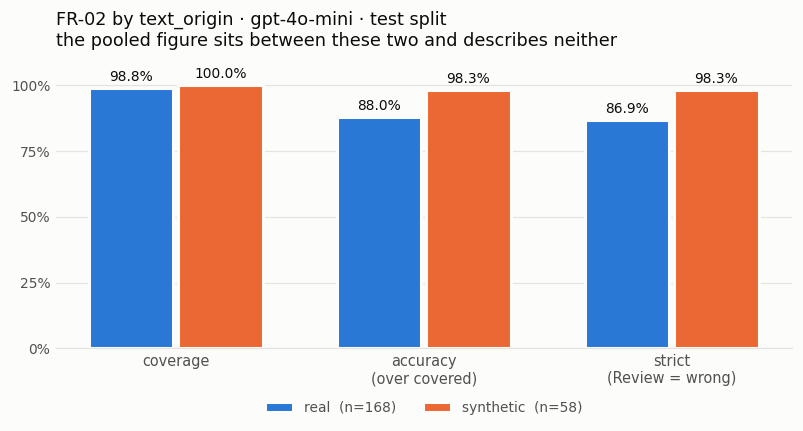

Every bar is directly labelled and the table above carries the same values.


In [19]:
metrics = ["coverage", "accuracy", "strict"]
groups = ["real", "synthetic"]
x = np.arange(len(metrics))
width = 0.34

fig, ax = plt.subplots(figsize=(7.4, 4.1))
for i, g in enumerate(groups):
    vals = [by_origin.loc[g, m] * 100 for m in metrics]
    # 2px surface gap between adjacent bars, via a small inset rather than a border.
    bars = ax.bar(x + (i - 0.5) * (width + 0.02), vals, width,
                  label=f"{g}  (n={int(by_origin.loc[g, 'n'])})",
                  color=SERIES[i], edgecolor=SURFACE, linewidth=2)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.6, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=9, color=INK)

ax.set_xticks(x, ["coverage", "accuracy\n(over covered)", "strict\n(Review = wrong)"], fontsize=9.5)
ax.set_ylim(0, 108)
ax.set_yticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"], fontsize=9)
ax.set_title(f"FR-02 by text_origin · {MODEL_UNDER_TEST} · test split\n"
             "the pooled figure sits between these two and describes neither",
             fontsize=11.5, pad=12, loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2,
          fontsize=9, labelcolor=INK_2)       # below the plot: never over a bar
tidy(ax)
fig.tight_layout()
plt.show()

print("Every bar is directly labelled and the table above carries the same values.")

### What this does and does not license you to say

- **The real-email figure is the FR-02 result.** It is measured on genuine human-written
  mail, and it describes how the product will behave on a user's inbox. If one
  categorisation number goes on a slide, it is **86.9% strict on real email (n=168)**:
  Review counted as a miss, generated mail left out.
- **The synthetic figure is close to ceiling and should never be quoted alone.** It is a
  single class of text written by a language model, now classified by one. It demonstrates
  that the pipeline works end to end; it does not demonstrate FR-02.
- **The pooled figure is an artefact of the mix.** It rises or falls with the proportion of
  generated rows in the set, independently of the classifier. That is why
  `eval/data/README.md` insists these columns never be collapsed, and why every table in
  this notebook reports the split.

## 7 · Coverage vs accuracy

The classifier can abstain. That makes a single accuracy figure manipulable, so this section
reports the three numbers together and then demonstrates *why*: by showing what happens to
each when abstention is tuned.

There are two distinct reasons a row reaches `Review`: the model's confidence fell below the
configured threshold, or the evidence it quoted could not be found in the email. Since run
11 the prediction file records which, row by row, so the bucket below is read from the file
rather than inferred. Only the first reason is tunable.

In [20]:
THRESHOLD = 0.7   # CLASSIFY_CONFIDENCE_THRESHOLD default, backend/config.py

print("The three numbers, together")
print("=" * 72)
print(f"  coverage             {overall['coverage']:6.1%}   "
      f"{overall['n'] - overall['reviewed']} of {overall['n']} rows answered")
print(f"  accuracy (covered)   {overall['accuracy']:6.1%}   correct, of those answered")
print(f"  strict               {overall['strict']:6.1%}   correct, of every row")
print()
print("  Each alone is misleading, and in a different direction:")
print("   - accuracy alone hides how often it declined to answer;")
print("   - coverage alone hides whether the answers were any good;")
print("   - strict alone punishes a safety feature working as designed, and cannot")
print("     distinguish 'wrong' from 'sent to a human on purpose'.")

reviewed = TEST[TEST["predicted"] == REVIEW]
print(f"\nThe Review bucket ({len(reviewed)} rows), by the reason the run recorded")
print("=" * 72)
for reason, n in reviewed["review_reason"].value_counts().items():
    print(f"  {reason:36} {n:3}")
print("\n  Only `low_confidence` is a threshold choice. `evidence_not_in_source` means")
print("  the quote the model gave as its evidence is not in the email, which no")
print("  threshold can recover, so the sweep below can only make the classifier MORE")
print("  cautious, never less.")

The three numbers, together
  coverage              99.1%   224 of 226 rows answered
  accuracy (covered)    90.6%   correct, of those answered
  strict                89.8%   correct, of every row

  Each alone is misleading, and in a different direction:
   - accuracy alone hides how often it declined to answer;
   - coverage alone hides whether the answers were any good;
   - strict alone punishes a safety feature working as designed, and cannot
     distinguish 'wrong' from 'sent to a human on purpose'.

The Review bucket (2 rows), by the reason the run recorded
  evidence_not_in_source                 2

  Only `low_confidence` is a threshold choice. `evidence_not_in_source` means
  the quote the model gave as its evidence is not in the email, which no
  threshold can recover, so the sweep below can only make the classifier MORE
  cautious, never less.


In [21]:
print("Is the confidence score calibrated? (covered rows only)\n")
covered = TEST[TEST["predicted"] != REVIEW].copy()
rows = []
for conf, sub in covered.groupby("confidence"):
    rows.append({"confidence": conf, "n": len(sub),
                 "accuracy": (sub["expected"] == sub["predicted"]).mean()})
calib = pd.DataFrame(rows).set_index("confidence")
out = calib.copy(); out["accuracy"] = calib["accuracy"].map("{:.1%}".format)
print(out.to_string())
monotonic = calib["accuracy"].is_monotonic_increasing
print(f"\nThe scores take {len(calib)} discrete values, and accuracy "
      f"{'rises' if monotonic else 'does NOT rise'} with them"
      f"{'' if monotonic else ': a higher score is not always a safer answer'}.")
print("Confidence is usable as a cheap abstention trigger, but it is not a probability")
print("and must not be shown to a user as one.")

Is the confidence score calibrated? (covered rows only)

              n accuracy
confidence              
0.7           2     0.0%
0.8           7    28.6%
0.9         166    91.6%
1.0          49   100.0%

The scores take 4 discrete values, and accuracy rises with them.
Confidence is usable as a cheap abstention trigger, but it is not a probability
and must not be shown to a user as one.


In [22]:
sweep = []
for t in sorted(TEST["confidence"].unique()):
    sim = TEST.copy()
    sim.loc[sim["confidence"] < t, "predicted"] = REVIEW    # can only ADD abstentions
    m = score(sim["expected"], sim["predicted"])
    sweep.append({"threshold": t, "coverage": m["coverage"], "accuracy": m["accuracy"],
                  "strict": m["strict"], "macro-F1": m["macro_f1"]})
sweep = pd.DataFrame(sweep).set_index("threshold")

f = sweep.copy()
for c in ["coverage", "accuracy", "strict"]:
    f[c] = sweep[c].map("{:.1%}".format)
f["macro-F1"] = sweep["macro-F1"].map("{:.3f}".format)
print(f"Simulated abstention threshold (shipped value = {THRESHOLD})\n")
print(f.to_string())

best_acc = sweep["accuracy"].idxmax()
print(f"\naccuracy-over-covered peaks at threshold {best_acc}: "
      f"{sweep.loc[best_acc, 'accuracy']:.1%} "
      f"(+{(sweep.loc[best_acc, 'accuracy'] - overall['accuracy']) * 100:.1f} pp)")
print(f"  ... but strict accuracy there is {sweep.loc[best_acc, 'strict']:.1%} "
      f"({(sweep.loc[best_acc, 'strict'] - overall['strict']) * 100:+.1f} pp) "
      f"and coverage falls to {sweep.loc[best_acc, 'coverage']:.1%} "
      f"({(sweep.loc[best_acc, 'coverage'] - overall['coverage']) * 100:+.1f} pp).")
print("\nNo email was classified better. Rows were moved out of the denominator.")

Simulated abstention threshold (shipped value = 0.7)

          coverage accuracy strict macro-F1
threshold                                  
0.7          99.1%    90.6%  89.8%    0.902
0.8          98.2%    91.4%  89.8%    0.906
0.9          95.1%    93.5%  88.9%    0.911
1.0          21.7%   100.0%  21.7%    0.329

accuracy-over-covered peaks at threshold 1.0: 100.0% (+9.4 pp)
  ... but strict accuracy there is 21.7% (-68.1 pp) and coverage falls to 21.7% (-77.4 pp).

No email was classified better. Rows were moved out of the denominator.


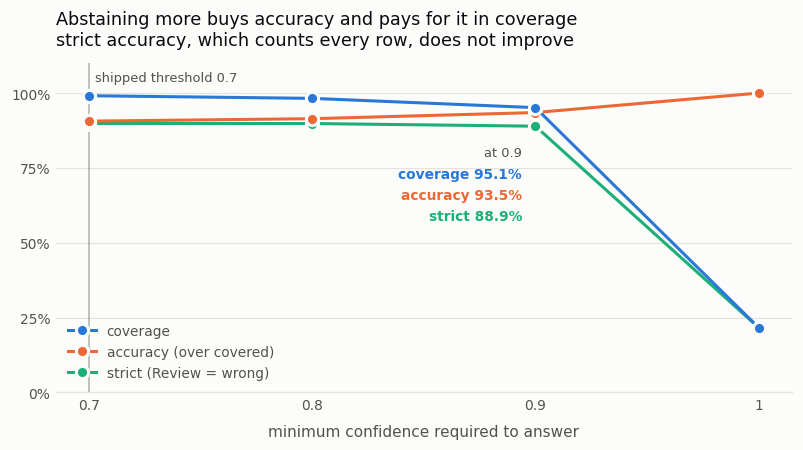

Simulated by raising the confidence floor on the SAVED predictions -- no model
calls. Lowering it cannot be simulated (see the decomposition above).


In [23]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
xs = sweep.index.to_numpy()
# Direct-label at the informative threshold (where the three separate), not at the
# degenerate right-hand end where coverage collapses and two of them converge.
label_at = float(sweep.index[sweep["coverage"] >= 0.5].max())
for i, (col, label) in enumerate([("coverage", "coverage"),
                                  ("accuracy", "accuracy (over covered)"),
                                  ("strict", "strict (Review = wrong)")]):
    ys = sweep[col].to_numpy() * 100
    ax.plot(xs, ys, color=SERIES[i], linewidth=2, marker="o", markersize=8,
            markeredgecolor=SURFACE, markeredgewidth=2, label=label, zorder=3 - i * 0.1)

# The values at label_at, in each series' colour, in the empty space under the lines
# and left of the point: to its right the lines fall steeply and would cross any label.
ax.text(label_at - 0.006, 80, f"at {label_at:g}", ha="right", va="center",
        fontsize=8.5, color=INK_2)
for k, (i, col) in enumerate([(0, "coverage"), (1, "accuracy"), (2, "strict")]):
    ax.text(label_at - 0.006, 73 - 7 * k, f"{col} {sweep.loc[label_at, col] * 100:.1f}%",
            ha="right", va="center", fontsize=9, color=SERIES[i], fontweight="bold")

ax.axvline(THRESHOLD, color=INK_2, linewidth=1, linestyle="-", alpha=0.45, zorder=1)
ax.annotate(f"shipped threshold {THRESHOLD}", (THRESHOLD, 104), fontsize=8.5,
            color=INK_2, ha="left", xytext=(4, 0), textcoords="offset points")

ax.set_xlabel("minimum confidence required to answer", labelpad=8)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"], fontsize=9)
ax.set_xticks(xs, [f"{v:g}" for v in xs], fontsize=9)
ax.set_title("Abstaining more buys accuracy and pays for it in coverage\n"
             "strict accuracy, which counts every row, does not improve",
             fontsize=11.5, pad=12, loc="left")
ax.legend(loc="lower left", fontsize=9, labelcolor=INK_2)
tidy(ax)
fig.tight_layout()
plt.show()

print("Simulated by raising the confidence floor on the SAVED predictions -- no model")
print("calls. Lowering it cannot be simulated (see the decomposition above).")

### Why quoting one of the three is misleading

The sweep is the proof. Raising the confidence floor to 0.9 lifts accuracy-over-covered
from 90.6% to 93.5% while **strict accuracy falls** (89.8% to 88.9%) and coverage drops by
four points. Nothing was classified better; rows were removed from the denominator. At 1.0
the system answers about a fifth of its email and reports 100% accuracy on those. A report
that quoted only accuracy-over-covered could show an improving classifier while the product
answered fewer and fewer emails.

Quoting only strict accuracy fails in the other direction: it treats a deliberate handover
to a human as though the system had confidently given a wrong answer, which is the one
outcome the design is trying to avoid. With 2 abstentions in 226 rows the two readings are
within a point of each other for this run; the batched holdout in §9 shows how far apart
they can be.

So all three are reported, always, with the batch size, and the strict figure is the one
to use if a single conservative bound is needed.

## 8 · FR-01 / FR-03: groundedness

Summarisation and drafting are not accuracy problems. A summary has no single correct
output, so there is nothing to be accurate *about*. What can be measured is whether the
system asserted anything the source email does not support: every number, amount, date,
time and proper noun in the output is checked against the preprocessed email, and an output
with zero unsupported claims is **grounded**.

    groundedness rate = outputs with zero ungrounded flags / outputs produced

Two rules from `evaluate_grounding.py` are load-bearing:

- **Production failures are never counted as grounded.** A summary that could not be
  produced is not a grounded summary. Folding those in would let a run that mostly crashed
  report a high score on the handful that survived, so they are reported separately.
- **The rate is meaningless without the claim count.** A groundedness rate computed over
  outputs that contain no numbers, dates or names would read 100% however badly the model
  behaved, because nothing was checked. The claims-per-output figure is what makes the rate
  mean anything, and it is treated as part of the result below.

In [24]:
def load_grounding(name):
    g = pd.read_csv(DATA / name, keep_default_na=False)
    # NB: g["flags"], never g.flags -- DataFrame.flags is a pandas attribute.
    g["is_grounded"] = g["grounded"].astype(str).str.strip().str.lower().eq("true")
    g["flag_count"] = g["flag_count"].astype(int)
    return g


GROUNDING = {"summarise": ("grounding_summarise.csv", "FR-01"),
             "draft": ("grounding_draft.csv", "FR-03")}
gr = {}
rows = []
for task, (fname, req) in GROUNDING.items():
    g = load_grounding(fname)
    gr[task] = g
    rows.append({
        "task": task, "requirement": req, "outputs produced": len(g),
        "grounded": int(g["is_grounded"].sum()),
        "flagged outputs": int((g["flag_count"] > 0).sum()),
        "total flags": int(g["flag_count"].sum()),
        "groundedness rate": g["is_grounded"].mean(),
    })
summary = pd.DataFrame(rows).set_index("task")
out = summary.copy()
out["groundedness rate"] = summary["groundedness rate"].map("{:.1%}".format)
print(out.to_string())

print("\nThe saved per-output files record only outputs that were PRODUCED. Attempted-but-")
print("failed rows (EmptyEmailError) are not in them, so the denominators above are")
print("'produced', which is the correct denominator for this rate -- but the attempted")
print("count and the failure count cannot be recovered from these files. They are in the")
print("run log in BENCHMARKS.md and are not restated here as if computed.")

          requirement  outputs produced  grounded  flagged outputs  total flags groundedness rate
task                                                                                             
summarise       FR-01                55        53                2            2             96.4%
draft           FR-03                38        37                1            1             97.4%

The saved per-output files record only outputs that were PRODUCED. Attempted-but-
failed rows (EmptyEmailError) are not in them, so the denominators above are
'produced', which is the correct denominator for this rate -- but the attempted
count and the failure count cannot be recovered from these files. They are in the
run log in BENCHMARKS.md and are not restated here as if computed.


In [25]:
for task, g in gr.items():
    print(f"{task}: by text_origin and category\n")
    rows = []
    for (origin, cat), sub in g.groupby(["text_origin", "category"]):
        rows.append({"text_origin": origin, "category": cat, "n": len(sub),
                     "grounded": sub["is_grounded"].mean()})
    t = pd.DataFrame(rows).set_index(["text_origin", "category"])
    show_t = t.copy(); show_t["grounded"] = t["grounded"].map("{:.1%}".format)
    print(show_t.to_string())
    for col in ["text_origin"]:
        agg = []
        for key, sub in g.groupby(col):
            agg.append({col: key, "n": len(sub), "grounded": f"{sub['is_grounded'].mean():.1%}"})
        print("\n" + pd.DataFrame(agg).set_index(col).to_string())
    print("\n" + "-" * 66 + "\n")

print("Both tasks are scored on the same balanced sample of classes, and in both the")
print("only flags fall on REAL email. The generated Studies rows are perfectly grounded,")
print("which is the same confound as §6: short, well-structured, model-written text is")
print("easier to summarise without inventing anything.")

summarise: by text_origin and category

                         n grounded
text_origin category               
real        Personal    13    92.3%
            Promotions  14   100.0%
            Work        13    92.3%
synthetic   Studies     15   100.0%

              n grounded
text_origin             
real         40    95.0%
synthetic    15   100.0%

------------------------------------------------------------------

draft: by text_origin and category

                         n grounded
text_origin category               
real        Personal     9   100.0%
            Promotions   9   100.0%
            Work        10    90.0%
synthetic   Studies     10   100.0%

              n grounded
text_origin             
real         28    96.4%
synthetic    10   100.0%

------------------------------------------------------------------

Both tasks are scored on the same balanced sample of classes, and in both the
only flags fall on REAL email. The generated Studies rows are perfectly gr

In [26]:
print("What was actually flagged: the whole list, since there are few enough to read\n")
for task, g in gr.items():
    flagged = g[g["flag_count"] > 0]
    print(f"{task}: {len(flagged)} flagged output(s) of {len(g)}")
    for _, r in flagged.iterrows():
        print(f"   [{r['category']}/{r['text_origin']}] {r['subject'][:58]}")
        print(f"      -> {r['flags']}")
    reasons = {}
    for s in g["flags"]:
        for m in re.finditer(r"\(([^()]*)\)", str(s)):
            reasons[m.group(1)] = reasons.get(m.group(1), 0) + 1
    print(f"   flag kinds: {reasons or 'none'}\n")

print("Every flag is a claim the checker could not find in the source. Reading")
print("them matters: at these sample sizes one flag moves the rate by ~2 pp, so the rate")
print("is a summary of a list short enough to inspect, and it was inspected.")

What was actually flagged: the whole list, since there are few enough to read

summarise: 2 flagged output(s) of 55
   [Personal/real] Continental Schedule IAH SJU  1st class
      -> Call Crystal (name does not appear in the source email)
   [Work/real] NYISO Training
      -> the NYISO Market Orientation Course (name does not appear in the source email)
   flag kinds: {'name does not appear in the source email': 2}

draft: 1 flagged output(s) of 38
   [Work/real] NYISO Training
      -> the NYISO Market Orientation Course (name does not appear in the source email)
   flag kinds: {'name does not appear in the source email': 1}

Every flag is a claim the checker could not find in the source. Reading
them matters: at these sample sizes one flag moves the rate by ~2 pp, so the rate
is a summary of a list short enough to inspect, and it was inspected.


### Claims checked per output

A groundedness rate is only interpretable next to how much was checked. An earlier version
of this notebook could not recompute this, because the run had saved only verdicts. Since
then `evaluate_grounding.py --out` writes a `claims_checked` column, and the runs used here
(run C of each, 2026-10-09) were made with it, so the figure is read from the CSV rather
than quoted from a log.

The source-side density after it is computed locally, with the same spaCy extractor the run
used and no API call: how much checkable material the emails contained, as a reference for
how much the outputs carried over.

In [27]:
print("Claims checked per output, read from the saved files")
print("=" * 72)
rows = []
for task, g in gr.items():
    c = g["claims_checked"].astype(int)
    rows.append({"task": task, "outputs": len(g), "claims checked": int(c.sum()),
                 "per output": c.mean(), "outputs with none": int((c == 0).sum()),
                 "grounded AND checked": int((g["is_grounded"] & (c > 0)).sum())})
claims = pd.DataFrame(rows).set_index("task")
out = claims.copy(); out["per output"] = claims["per output"].map("{:.1f}".format)
print(out.to_string())
print("\n'grounded AND checked' is the count the rate rests on: outputs that made at")
print("least one checkable claim and had every one of them confirmed. An output with")
print("nothing to check counts as grounded too, which is why the column beside it is")
print("printed: it says how much of each rate is an empty check.")

Claims checked per output, read from the saved files
           outputs  claims checked per output  outputs with none  grounded AND checked
task                                                                                  
summarise       55             197        3.6                  7                    46
draft           38              69        1.8                  8                    29

'grounded AND checked' is the count the rate rests on: outputs that made at
least one checkable claim and had every one of them confirmed. An output with
nothing to check counts as grounded too, which is why the column beside it is
printed: it says how much of each rate is an empty check.


In [28]:
# Source-side claim density: how much checkable material was in the emails that were
# scored. Deterministic, local, no model call. It is a reference for the per-output
# figure above, not a substitute for it.
claim_density = None
try:
    from backend.orchestrator import grounding as gmod
    gmod._load_spacy()
    backend_name = gmod.ENTITY_BACKEND
    print(f"entity backend: {backend_name}"
          f"{'  (same extractor the recorded run used)' if backend_name == 'spacy' else ''}")
    if backend_name != "spacy":
        print("  WARNING: spaCy unavailable; the weaker capitalisation heuristic is in use,")
        print("  so the counts below are NOT comparable to the recorded run.")

    rows = []
    for task, g in gr.items():
        sub = ds[ds["id"].isin(set(g["id"]))]
        counts = []
        for _, r in sub.iterrows():
            text = f"{r['subject']}\n{r['body']}"
            counts.append(len(gmod.extract_typed_claims(text))
                          + len(gmod.extract_proper_nouns(text)))
        counts = np.array(counts)
        rows.append({"task": task, "emails": len(counts),
                     "checkable claims in SOURCE": int(counts.sum()),
                     "per email": counts.mean(),
                     "median": float(np.median(counts)),
                     "emails with none": int((counts == 0).sum())})
    claim_density = pd.DataFrame(rows).set_index("task")
    out = claim_density.copy()
    out["per email"] = claim_density["per email"].map("{:.1f}".format)
    print()
    print(out.to_string())
    print("\nRead this as: the emails being summarised are dense with checkable material,")
    print("so a summary of them has ample opportunity to fabricate. That is the premise")
    print("the groundedness rate rests on. A summary carries a subset of its source's")
    print("claims, so the per-output figure above is the one to quote, not this.")
except Exception as exc:
    print(f"Source-side claim density unavailable ({type(exc).__name__}: {exc}).")
    print("This cell is optional; it needs backend.orchestrator.grounding and the spaCy")
    print("model en_core_web_sm. No metric reported elsewhere depends on it.")

entity backend: spacy  (same extractor the recorded run used)



           emails  checkable claims in SOURCE per email  median  emails with none
task                                                                             
summarise      55                         615      11.2     7.0                 1
draft          38                         439      11.6     7.0                 1

Read this as: the emails being summarised are dense with checkable material,
so a summary of them has ample opportunity to fabricate. That is the premise
the groundedness rate rests on. A summary carries a subset of its source's
claims, so the per-output figure above is the one to quote, not this.


### What a groundedness flag does and does not mean

Both directions have to be stated, because the metric is asymmetric and easy to over-read.

- **A flag is evidence of a problem, not proof of one.** It means a token in the output is
  not in the source. A legitimate paraphrase can flag: "next Friday" for a date written
  out in full, or a name the model reasonably expanded. The flagged rows listed above are
  exactly this kind of judgement call, which is why the list is short enough to read and was
  read.
- **Zero flags does not mean the summary is true.** It means nothing *checkable* is
  missing. A summary can be grounded in every name and number and still misrepresent the
  email's point entirely, and this metric will not notice.

The measured rates also reflect the verifier corrections recorded in `BENCHMARKS.md`:
proper-noun handling that strips leading articles, possessives and salutations, and dates,
weekdays and two-digit years compared by meaning rather than spelling. Each was found by
inspecting flagged output, confirmed as a false positive and fixed narrowly, with regression
tests proving genuine fabrications are still caught. They raised the measured numbers by
making the measurement correct, not by weakening the check, but they are a reminder that a
groundedness figure is only meaningful with its verifier version and entity backend stated
alongside it.

One caution specific to these files: run C scored mostly the same emails as the run before
it (54 of 55 summaries, 37 of 38 drafts), and its summary rate is two outputs higher.
Today's checker still flags both of the earlier run's claims as they were worded then, so
the model simply did not repeat them. At n=55, two outputs is 3.6 points: the two runs agree.

## 9 · One email per call vs 20 per call, on rows nobody had scored

The shipped configuration's most consequential choice is not the model, it is sending one
email per call. Both holdout files were made on the same 123 verified rows, which no
configuration had been scored on before, with the same model, prompt, verifier and
threshold; only the batch size differs. That makes this the cleanest like-for-like in the
project, and it costs nothing to recompute.

In [29]:
ONE = preds["holdout_preds_per_email.csv"].copy()
TWENTY = preds["holdout_preds_batch20.csv"].copy()
assert set(ONE["id"]) == set(TWENTY["id"]), "the two holdout files do not cover the same rows"
assert ONE["model"].nunique() == TWENTY["model"].nunique() == 1 \
    and ONE["model"].iloc[0] == TWENTY["model"].iloc[0], "the model differs"

# Every holdout row must still carry the label it was scored against: most are in
# holdout_unscored.csv, and the 400-row merge moved the rest into dataset.csv.
hold = pd.read_csv(DATA / "holdout_unscored.csv", keep_default_na=False)
label_now = {**dict(zip(hold["id"], hold["category"])), **dict(zip(ds["id"], ds["category"]))}
assert all(label_now[i] == e for i, e in zip(ONE["id"], ONE["expected"])), "a holdout label changed"
moved = int(ONE["id"].isin(ds["id"]).sum())
print(f"same {len(ONE)} rows, model {ONE['model'].iloc[0]}, batch size the only difference "
      f"({int(TWENTY['classify_batch_size'].iloc[0])} per call vs "
      f"{int(ONE['classify_batch_size'].iloc[0])})")
print(f"labels unchanged since the run: yes ({len(ONE) - moved} still in holdout_unscored.csv, "
      f"{moved} since merged into dataset.csv)\n")

rows = {}
for name, df in [("20 per call", TWENTY), ("one per call", ONE)]:
    for subset, sub in [("all", df), ("real only", df[df["text_origin"] == "real"])]:
        m = score(sub["expected"], sub["predicted"])
        rows[(name, subset)] = {"n": m["n"], "coverage": f"{m['coverage']:.1%}",
                                "accuracy": f"{m['accuracy']:.1%}", "strict": f"{m['strict']:.1%}",
                                "macro-F1": f"{m['macro_f1']:.3f}"}
print(pd.DataFrame(rows).T.to_string())


def mcnemar_exact(b, c):
    """Two-sided exact McNemar p-value: a binomial test on the discordant pairs."""
    n = b + c
    tail = sum(math.comb(n, k) for k in range(min(b, c) + 1)) / 2 ** n
    return min(1.0, 2 * tail)


pair = ONE[["id", "text_origin", "expected", "predicted"]].merge(
    TWENTY[["id", "predicted"]], on="id", suffixes=("_one", "_twenty"))
right_one = pair["predicted_one"] == pair["expected"]
right_twenty = pair["predicted_twenty"] == pair["expected"]
print("\nPaired, Review counted as wrong (exact McNemar)")
for subset, mask in [("all", pair["id"].notna()), ("real only", pair["text_origin"] == "real")]:
    b = int((right_one & ~right_twenty & mask).sum())
    c = int((~right_one & right_twenty & mask).sum())
    print(f"  {subset:10} only one-per-call right: {b:3}   only batched right: {c:3}   "
          f"p = {mcnemar_exact(b, c):.1e}")

print("\nWhy rows went to Review")
reasons = pd.DataFrame({"20 per call": TWENTY["review_reason"].value_counts(),
                        "one per call": ONE["review_reason"].value_counts()}).fillna(0).astype(int)
print(reasons.drop(index="", errors="ignore").to_string())

same 123 rows, model gpt-4o-mini, batch size the only difference (20 per call vs 1)
labels unchanged since the run: yes (106 still in holdout_unscored.csv, 17 since merged into dataset.csv)

                          n coverage accuracy strict macro-F1
20 per call  all        123    82.9%    76.5%  63.4%    0.733
             real only   97    80.4%    74.4%  59.8%    0.706
one per call all        123    96.7%    89.9%  87.0%    0.894
             real only   97    95.9%    87.1%  83.5%    0.877

Paired, Review counted as wrong (exact McNemar)
  all        only one-per-call right:  30   only batched right:   1   p = 3.0e-08
  real only  only one-per-call right:  24   only batched right:   1   p = 1.5e-06

Why rows went to Review
                             20 per call  one per call
review_reason                                         
evidence_not_in_source                16             2
low_confidence                         3             2
missing_from_model_response            2 

**The gain is large, and it is real.** One email per call adds 23.6 points of strict
accuracy on the holdout, and 23.7 on its real email. Paired row by row, 30 rows only the
unbatched run got right against 1 the other way: a split that size is not noise.

The Review table shows where it comes from. Asked to keep 20 judgements and 20 verbatim
evidence quotes apart in one response, the model misquoted its evidence for 16 emails and
left 2 out of its answer altogether; one email per call misquoted 2 and dropped none. The
cost is that the instructions travel with every email: US\$0.15 per 1,000 emails classified,
against US\$0.06 batched (`eval/data/compare/REPORT.md`), still well inside the \$5/week
budget.

Two cautions. The holdout has no Work class (every verified Work row was already in the
dataset when it was drawn) and is harder than the test split for both settings, so compare
its rows with each other, not with §4. And 17 of its rows have since been merged into the
400-row dataset; their labels are unchanged (checked above) and both prediction files keep
all 123, so the comparison still recomputes.

**On the model.** gpt-4o-mini was kept over gpt-4o on the 480-row set (runs 7 to 9: three to
four points of covered accuracy and under a point strict, for roughly 15× the cost), and it
was compared against eight other models on the 376-row set in
`eval/data/compare/REPORT.md`. Those files predate today's dataset, so they are not
recomputed here; `BENCHMARKS.md` has both comparisons.

## 10 · Limitations

Every figure above is honest about what it measures and fragile in ways a reader cannot see
from the number alone. These are the four that matter most.

### 10.1 · The `Work` labels were wrong, and were corrected

The `Work` rows were first labelled by folder: the label meant only "it was in the inbox".
All of them were then read by a person, row by row, against a proposed label, and about a
fifth of them were not Work at all: spam, club flyers, fantasy-football threads, a note from
a spouse. The corrections were applied before run 10, so every figure above is measured
against the verified labels.

In [30]:
review = pd.read_csv(DATA / "review_work.csv", keep_default_na=False)
verdict = review["verified"].astype(str).str.strip()
# "y" accepts the proposed label; anything else is the label the reader chose instead.
review["final"] = np.where(verdict.str.lower() == "y", review["proposed_category"], verdict)

print(f"Work rows first labelled by folder   {len(review)}")
print(f"read and decided by a person         {int((verdict != '').sum())} of {len(review)}")
print(f"proposal overruled by the reader     {int(((verdict.str.lower() != 'y') & (verdict != '')).sum())}")
print("\nFinal label for the rows the folder had called Work")
print(review["final"].value_counts().to_frame("rows").to_string())
not_work = int((review["final"] != "Work").sum())
print(f"\nnot Work: {not_work} of {len(review)} = {not_work / len(review):.1%} of the class")

now = review.merge(ds[["id", "category", "label_source"]], on="id", how="left")
in_ds = now["category"].notna()
print(f"\nof those {len(review)} rows, {int(in_ds.sum())} are in today's dataset "
      f"(the rest fell outside the 100-per-class cap)")
print(f"  every one carries its verified label: {bool((now.loc[in_ds, 'category'] == now.loc[in_ds, 'final']).all())}")
print(f"  every one is labelled `human`:        {bool((now.loc[in_ds, 'label_source'] == 'human').all())}")

Work rows first labelled by folder   120
read and decided by a person         120 of 120
proposal overruled by the reader     1

Final label for the rows the folder had called Work
            rows
final           
Work          94
Promotions    13
Personal      13

not Work: 26 of 120 = 21.7% of the class

of those 120 rows, 107 are in today's dataset (the rest fell outside the 100-per-class cap)
  every one carries its verified label: True
  every one is labelled `human`:        True


In [31]:
# The rows the folder got wrong, as run 13 saw them. They are in today's test split
# under their corrected label, so this is how the classifier does on exactly the mail
# a folder heuristic would have scored against the wrong answer.
moved = review.loc[review["final"] != "Work", ["id", "final"]]
seen = TEST.merge(moved, on="id")
right = int((seen["predicted"] == seen["expected"]).sum())
print(f"corrected rows in today's test split: {len(seen)}")
print(seen["expected"].value_counts().to_frame("rows").to_string())
print(f"\nrun 13 puts {right} of {len(seen)} in their corrected class; "
      f"{int((seen['predicted'] == 'Work').sum())} it still calls Work.")
print("Under the folder labels every one of those right answers would have been scored")
print("as a miss: that is the measurement error the correction removed.")

corrected rows in today's test split: 8
            rows
expected        
Personal       4
Promotions     4

run 13 puts 8 of 8 in their corrected class; 0 it still calls Work.
Under the folder labels every one of those right answers would have been scored
as a miss: that is the measurement error the correction removed.


**Read the last cell as what the correction was worth, not as a score.** Eight rows in
today's test split are emails the folder had called Work, and run 13 puts all eight in the
class a person decided they belong to. Under the folder labels each of those right answers
would have counted as a miss: the old labels did not just add noise, they marked the
classifier wrong where it was right. That is why runs before the correction must not be
compared with runs after it as if the classifier had changed (`BENCHMARKS.md`, "Corrected
before run 10").

### 10.2 · Run-to-run variance: a row or two, now that classification is unbatched

`temperature=0` is not determinism: the provider does not guarantee identical output for
identical input. Under batched classification that showed up as a few tenths of a point
between two runs of the same model, prompt, rows and batch size (runs 8 and 9 in
`BENCHMARKS.md`), because the other emails in a batch change what each one is classified
alongside.

One email per call removes the neighbours. The cell below compares two separate executions
of the same unbatched configuration on the same 215 rows: run 11, through the backend's own
`classify_emails`, and the model comparison's unbatched gpt-4o-mini run, through its own adapter, a
day apart.

The consequences for quoting:

- **Do not quote more than one decimal place.** One row of the test split is 0.4 points.
- **State the batch size** with any figure: one email per call throughout, except where §9
  says otherwise.
- **Every figure here is a single run** with no confidence interval of its own; the cell
  below is the evidence that a second run lands on the same predictions.

In [32]:
# Two separate executions of the same unbatched configuration on the same rows: run 11
# (the backend's own classify_emails) and the model comparison's gpt-4o-mini run (its
# own adapter), a day apart. Neither was re-run for this notebook.
r11 = preds["test_preds_run11_per_email.csv"]
other = pd.read_csv(DATA / "compare" / "classify_gpt-4o-mini+unbatched_test_r1.csv",
                    keep_default_na=False)
both = r11[["id", "predicted"]].merge(other[["id", "predicted"]], on="id",
                                      suffixes=("_run11", "_compare"))
agree = int((both["predicted_run11"] == both["predicted_compare"]).sum())
print(f"one email per call, run twice: {agree} of {len(both)} predictions agree")
print(f"strict accuracy: run 11 {headline(r11)['strict']:.1%}, "
      f"comparison run {headline(other)['strict']:.1%}")

one email per call, run twice: 215 of 215 predictions agree
strict accuracy: run 11 90.7%, comparison run 90.7%


### 10.3 · ROUGE is not reported, and that is deliberate

In [33]:
# The ROUGE argument, checked against the data rather than asserted. DATASET_COLUMNS is
# the schema as stored on disk, so the `split` column derived in §2 is not counted here.
candidates = [c for c in DATASET_COLUMNS
              if re.search(r"summar|referenc|abstract|gold|target|gist", c, re.I)]
print(f"columns in dataset.csv: {DATASET_COLUMNS}")
print(f"columns that could serve as a reference summary: {candidates or 'NONE'}")
print(f"\nrows in DR-01: {len(ds)}   reference summaries available: 0")
print("\nROUGE scores n-gram overlap against a reference summary. There is no reference")
print("summary in this dataset and no column that could stand in for one, so ROUGE is")
print("not merely unreported here -- it is not computable on DR-01 at all. Producing it")
print(f"would first require hand-writing {len(ds)} reference summaries.")

columns in dataset.csv: ['id', 'provenance', 'text_origin', 'label_source', 'label_confidence', 'category', 'subject', 'body', 'sender', 'received_at', 'source_ref']
columns that could serve as a reference summary: NONE

rows in DR-01: 400   reference summaries available: 0

ROUGE scores n-gram overlap against a reference summary. There is no reference
summary in this dataset and no column that could stand in for one, so ROUGE is
not merely unreported here -- it is not computable on DR-01 at all. Producing it
would first require hand-writing 400 reference summaries.


And it would still not answer the question. ROUGE cannot detect hallucination: a fluent,
wholly fabricated summary that reuses the email's vocabulary scores *well*, and that is
precisely the failure this project exists to catch. So the work would be large, the number
would be weak, and the risk would remain unmeasured. Groundedness is reported instead
because it addresses the actual risk. If ROUGE appears in the RTM, the cell above is the
work it implies, and §8 is the metric that was chosen in its place.

### 10.4 · Things these numbers cannot tell you

- **Sample size.** The test split is 226 rows (168 of them real email), and the grounding
  samples are smaller still: 55 summaries and 38 drafts. At that size a single output moves
  a groundedness rate by about two points, so those rates are indicative, not precise. They
  are quoted with their denominators throughout for that reason.
- **The grounding samples are not held out.** They are the first rows of each class in file
  order, dev and test alike, and the proper-noun corrections in §8 were made between two
  runs on largely the same sample.
- **The `Personal` class is a defined subpopulation, not a random sample.** Its rows were
  recovered from the Enron archive by *structural* signals (consumer mail domain, few
  recipients, no bulk sender, shallow forward chain), deliberately not keyword signals,
  since selecting personal mail by the words that make it obviously personal would produce
  a class of easy cases and flatter the classifier. The consequence is that the class means
  *personal mail arriving at a corporate inbox, usually from an outside address*. Personal
  mail between two colleagues on internal addresses is under-represented, because the
  domain signal cannot see it.
- **One corpus, one era.** Three of the four classes are Enron mail from 2001–02. Nothing
  here measures performance on modern HTML marketing mail, on non-English mail, or on any
  individual user's inbox.
- **Not in this notebook.** FR-05 voice-intent dispatch accuracy, NFR-01 latency and FR-07
  translation are measured in `eval/BENCHMARKS.md`, outside DR-02. None of them should be
  quoted from here.

## 11 · DR-02 coverage

Every item the RTM names, and where it is computed. The cell below rebuilds each figure
from the same saved files, so the checklist is a computed summary rather than a claim.

In [34]:
real_row = by_origin.loc["real"]
synth_row = by_origin.loc["synthetic"]
hold_all = score(ONE["expected"], ONE["predicted"])
hold_real_rows = ONE[ONE["text_origin"] == "real"]
hold_real = score(hold_real_rows["expected"], hold_real_rows["predicted"])

print(f"DR-02: labelled dataset as ground truth · {MODEL_UNDER_TEST} · "
      f"held-out test split, n={overall['n']}, {BATCH_SIZE} email per call, temperature 0")
print("=" * 86)
items = [
    ("ground-truth dataset",  f"{len(ds)} rows, {len(CLASSES)} classes, "
                              f"{int((ds['text_origin'] == 'real').sum())} real / "
                              f"{int((ds['text_origin'] == 'synthetic').sum())} synthetic, "
                              f"{int((ds['label_source'] == 'human').sum())} labels read by a person", "§1"),
    ("accuracy (covered)",    f"{overall['accuracy']:.1%}", "§4"),
    ("accuracy (strict)",     f"{overall['strict']:.1%}", "§4, §7"),
    ("coverage",              f"{overall['coverage']:.1%}", "§4, §7"),
    ("precision, per class",  ", ".join(f"{k} {v['precision']:.1%}"
                                        for k, v in overall["per_class"].items()), "§4"),
    ("recall, per class",     ", ".join(f"{k} {v['recall']:.1%}"
                                        for k, v in overall["per_class"].items()), "§4"),
    ("F1, per class",         ", ".join(f"{k} {v['f1']:.3f}"
                                        for k, v in overall["per_class"].items()), "§4"),
    ("macro-F1",              f"{overall['macro_f1']:.3f}", "§4"),
    ("confusion matrix",      f"{cm.shape[0]}x{cm.shape[1]} (4 classes + Review), table and plot", "§5"),
    ("strict on REAL email",  f"{real_row['strict']:.1%}  (n={int(real_row['n'])})  "
                              "<-- the FR-02 figure to quote", "§6"),
    ("strict on synthetic",   f"{synth_row['strict']:.1%}  (n={int(synth_row['n'])})  "
                              "not a capability result", "§6"),
    ("holdout, strict",       f"{hold_all['strict']:.1%} (n={hold_all['n']}); real email "
                              f"{hold_real['strict']:.1%} (n={hold_real['n']})", "§9"),
    ("FR-01 groundedness",    f"{summary.loc['summarise', 'groundedness rate']:.1%} "
                              f"({int(summary.loc['summarise', 'grounded'])}/"
                              f"{int(summary.loc['summarise', 'outputs produced'])} produced)", "§8"),
    ("FR-03 groundedness",    f"{summary.loc['draft', 'groundedness rate']:.1%} "
                              f"({int(summary.loc['draft', 'grounded'])}/"
                              f"{int(summary.loc['draft', 'outputs produced'])} produced)", "§8"),
    ("claims checked / output", f"{claims.loc['summarise', 'per output']:.1f} per summary, "
                                f"{claims.loc['draft', 'per output']:.1f} per draft", "§8"),
    ("ROUGE",                 "not computable on DR-01: 0 reference summaries", "§10.3"),
]
for name, value, where in items:
    print(f"  {name:24} {where:8} {value}")

print("\n" + "=" * 86)
print("Single-run figures. Unbatched, two executions of the same configuration agreed")
print("on every prediction (§10.2), so the noise is a row or two, not half a point.")
print("\nIf one number goes on a slide, it is the strict real-email figure above, with its n.")

DR-02: labelled dataset as ground truth · gpt-4o-mini · held-out test split, n=226, 1 email per call, temperature 0
  ground-truth dataset     §1       400 rows, 4 classes, 300 real / 100 synthetic, 300 labels read by a person
  accuracy (covered)       §4       90.6%
  accuracy (strict)        §4, §7   89.8%
  coverage                 §4, §7   99.1%
  precision, per class     §4       Work 94.7%, Personal 81.8%, Promotions 88.7%, Studies 96.6%
  recall, per class        §4       Work 81.8%, Personal 86.5%, Promotions 94.0%, Studies 98.3%
  F1, per class            §4       Work 0.878, Personal 0.841, Promotions 0.913, Studies 0.974
  macro-F1                 §4       0.902
  confusion matrix         §5       4x5 (4 classes + Review), table and plot
  strict on REAL email     §6       86.9%  (n=168)  <-- the FR-02 figure to quote
  strict on synthetic      §6       98.3%  (n=58)  not a capability result
  holdout, strict          §9       87.0% (n=123); real email 83.5% (n=97)
  FR-01 